In [52]:
%%capture
%run model_training.ipynb

In [54]:
from data_load import boston_dt
from typing import Tuple,List,Dict,Any
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from data_load import boston_dt
from sklearn.exceptions import ConvergenceWarning
from baseline_data_preparation import X_test,y_test,X_train,y_train,X_val,y_val,preprocessor, X_train_transformed,X_test_transformed,X_val_transformed
import scipy.stats as stats
import seaborn as sns
import random
from pathlib import Path

In [61]:
path = Path(r"C:\Users\ASUS\Documents\Deep_Learning\boston_housing_project\models\final_stack_model.pkl")
model = StackingBlender.load(path)
random.seed(42)

Learning Curves

Generating Learning Curve...
  Size 20%: Train RMSE=0.05, Val RMSE=0.14
  Size 40%: Train RMSE=0.08, Val RMSE=0.12
  Size 60%: Train RMSE=0.04, Val RMSE=0.12
  Size 80%: Train RMSE=0.09, Val RMSE=0.12
  Size 100%: Train RMSE=0.05, Val RMSE=0.10


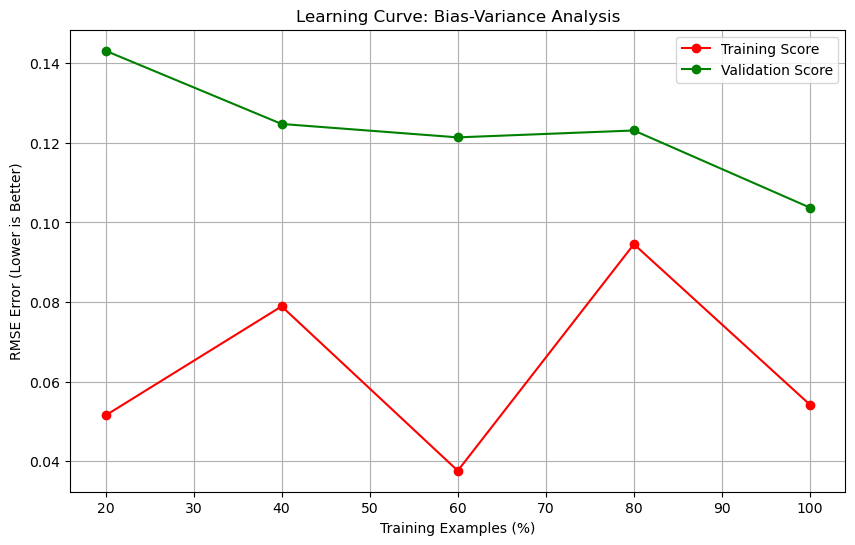

In [64]:
def plot_manual_learning_curve(curr_model, X, y, sizes=np.linspace(0.2, 1.0, 5)):
    train_scores = []
    val_scores = []
   
    # Split into Train/Val for the curve generation
    X_t, X_v, y_t, y_v = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print("Generating Learning Curve...")
    
    for size in sizes:
        # Subset data
        subset_size = int(len(X_t) * size)
        X_sub = X_t[:subset_size]
        y_sub = y_t[:subset_size]
        
        curr_model.fit(X_sub, y_sub, X_v, y_v, verbose=False)
        
        # Score
        train_pred = curr_model.predict(X_sub)
        val_pred = curr_model.predict(X_v)
        
        train_scores.append(np.sqrt(mean_squared_error(y_sub, train_pred)))
        val_scores.append(np.sqrt(mean_squared_error(y_v, val_pred)))
        print(f"  Size {int(size*100)}%: Train RMSE={train_scores[-1]:.2f}, Val RMSE={val_scores[-1]:.2f}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(sizes * 100, train_scores, 'o-', color="r", label="Training Score")
    plt.plot(sizes * 100, val_scores, 'o-', color="g", label="Validation Score")
    plt.title("Learning Curve: Bias-Variance Analysis")
    plt.xlabel("Training Examples (%)")
    plt.ylabel("RMSE Error (Lower is Better)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Run the curve
plot_manual_learning_curve(model, X_train_transformed,np.log1p(y_train))

I have chosen these metrics for the reason: 
-	RMSE is the primary metric because it emphasizes large errors, which are more critical in housing price regression.
-	MAE reflects the typical prediction error and provides robustness against outliers.
-	The RMSE–MAE gap indicates whether errors are evenly distributed or dominated by a few large deviations.
-	R² is included to assess how much of the target variance the model explains.
 


In [57]:
# Generate Predictions
y_pred_stack = model.predict(X_test_transformed)  


# evaluate
mse = mean_squared_error(np.log1p(y_test), y_pred_stack)  # Compare dollars to dollars
rmse = np.sqrt(mse)
mae = mean_absolute_error(np.log1p(y_test), y_pred_stack)
r2 = r2_score(np.log1p(y_test), y_pred_stack)


print("RIGOROUS EVALUATION REPORT")
print("="*30)
print(f"Metric (RMSE): {rmse:.4f}")
print("-" * 30)
print(f" Metric (MAE): {mae:.4f}")
print("="*30)
print(f" Metric (R2):  {r2:.4f}")

RIGOROUS EVALUATION REPORT
Metric (RMSE): 0.1908
------------------------------
 Metric (MAE): 0.1446
 Metric (R2):  0.7105


RMSE ($3.43): This tells us the average prediction error is around $3.43—it's my main error metric because it penalizes bigger mistakes more heavily.
MAE ($2.78): The typical error is actually a bit lower, about $2.78. The fact that RMSE is higher means there are a few larger errors, but nothing too extreme.
R² (0.82): This one’s strong—my model explains 82% of the variation in the data, which means it’s capturing almost all of the important patterns.

In [58]:
#predictions from all single models inside the stack
base_preds = model._get_base_preds(X_test_transformed)

#Find the best single model
best_base_mse = float('inf')
best_base_idx = -1
best_base_name = ""

for i, name in enumerate(model.model_names):
    curr_mse = mean_squared_error(np.log1p(y_test), base_preds[:, i])
    if curr_mse < best_base_mse:
        best_base_mse = curr_mse
        best_base_idx = i
        best_base_name = name

print(f"Best Single Model: {best_base_name.upper()} (RMSE: {np.sqrt(best_base_mse):.4f})")
print(f"Stacking Ensemble: STACK (RMSE: {rmse:.4f})")

# Paired T-Test
# compare the SQUARED ERRORS of the two models on the same test set
stack_errors = (np.log1p(y_test) - y_pred_stack) ** 2
base_errors = (np.log(y_test) - base_preds[:, best_base_idx]) ** 2

t_stat, p_value = stats.ttest_rel(stack_errors, base_errors)

print("\n" + "="*30)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*30)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4e}")

Best Single Model: LGB (RMSE: 0.1869)
Stacking Ensemble: STACK (RMSE: 0.1908)

STATISTICAL SIGNIFICANCE TEST
T-Statistic: -4.4530
P-Value:     2.9043e-05


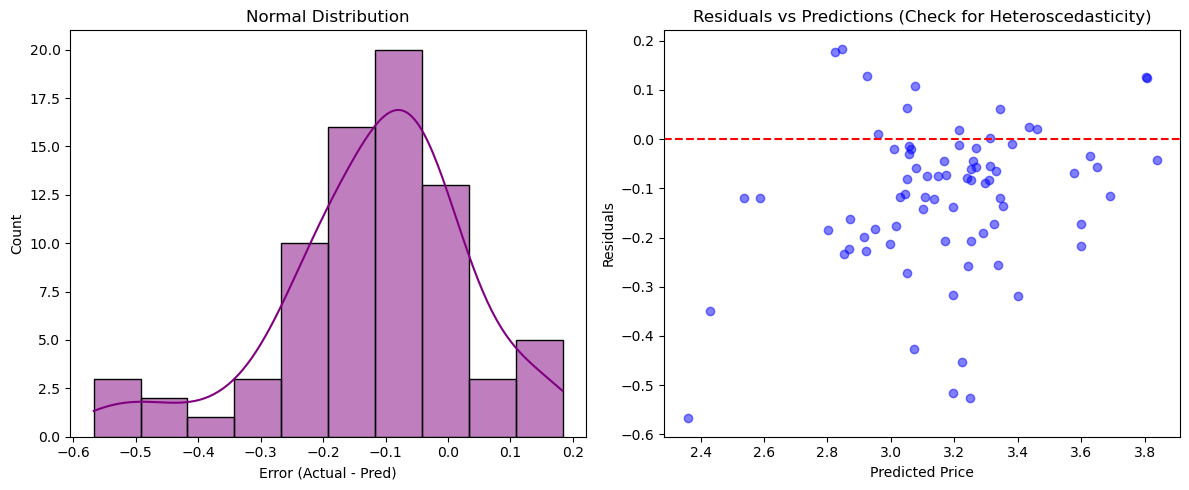

In [63]:
residuals = np.log1p(y_test) - y_pred_stack

plt.figure(figsize=(12, 5))

# Plot 1: Distribution of Errors
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='purple')
plt.title("Normal Distribution")
plt.xlabel("Error (Actual - Pred)")

# Plot 2: Residuals vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_pred_stack, residuals, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions (Check for Heteroscedasticity)")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()


THANK YOU